<a href="https://colab.research.google.com/github/24cseaiml040nilamanikundu/aml-lab/blob/main/Experiment5/aml_lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter the x values: 1,2,3,4
Enter the y values: 2,2,4,5
Enter learning rate: 0.05
Enter number of iterations: 20
Enter lambda: 0.2
Weight (w): 1.0905705825430423
Bias (b): 0.4506626295555878


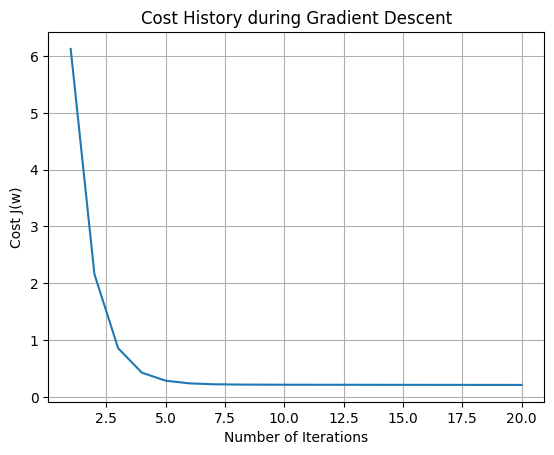

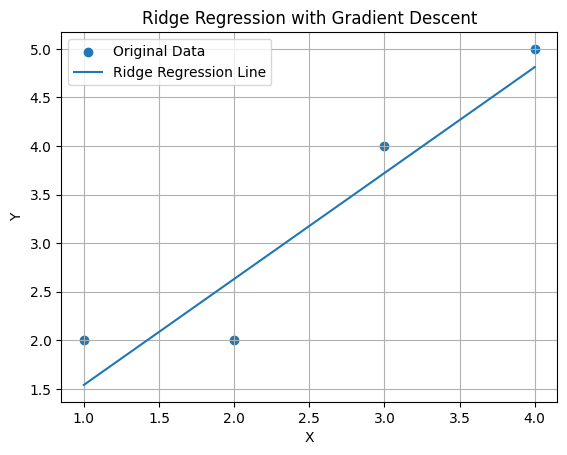

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def ridge_regression_gd(x, y, learning_rate, n_iter, lam):
    n = len(y)
    w = 0.0
    b = 0.0
    cost_history = []

    for i in range(n_iter):
        y_pred = w * x + b

        cost = (1/(2*n)) * np.sum((y_pred-y)**2) + (lam/2) * (w**2)
        cost_history.append(cost)

        dw = (1/n) * np.sum((y_pred-y)*x) + lam*w
        db = (1/n) * np.sum(y_pred-y)

        w = w - learning_rate * dw
        b = b - learning_rate * db

    return w, b, cost_history


x_input = input("Enter the x values: ")
y_input = input("Enter the y values: ")

x = np.array([float(v) for v in x_input.split(',')])
y = np.array([float(v) for v in y_input.split(',')])

learning_rate = float(input("Enter learning rate: "))
n_iter = int(input("Enter number of iterations: "))
lam = float(input("Enter lambda: "))

w, b, cost_history = ridge_regression_gd(
    x, y, learning_rate, n_iter, lam
)

print("Weight (w):", w)
print("Bias (b):", b)

plt.figure()
plt.plot(
    range(1, n_iter + 1),
    cost_history
)
plt.xlabel("Number of Iterations")
plt.ylabel("Cost J(w)")
plt.title("Cost History during Gradient Descent")
plt.grid(True)
plt.show()

sqrt_x = np.sqrt(x)
x_sorted = x[np.argsort(x)]

plt.figure()
plt.scatter(x, y, label="Original Data")

plt.plot(
    x_sorted,
    w * x_sorted + b,
    label="Ridge Regression Line"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Ridge Regression with Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

Enter x1 values: 2,4,6,7
Enter x2 values: 4,6,8,5
Enter target y values: 2,14,12,8
Enter learning rate: 0.1
Enter number of iterations: 20
Enter lambda: 0.5

Final Parameters:
w1 = -100209353544671.72
w2 = -117179013016182.06
b = -19233335000766.36


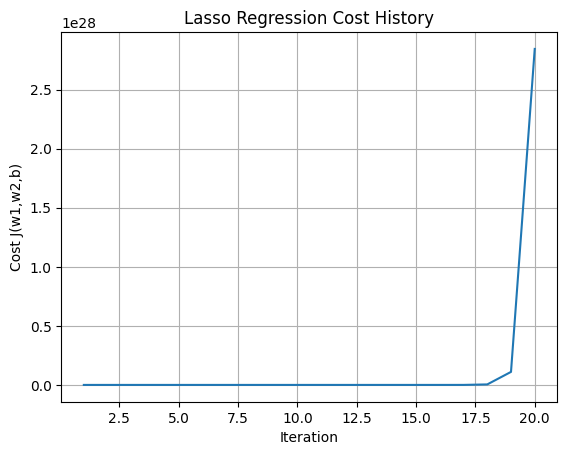

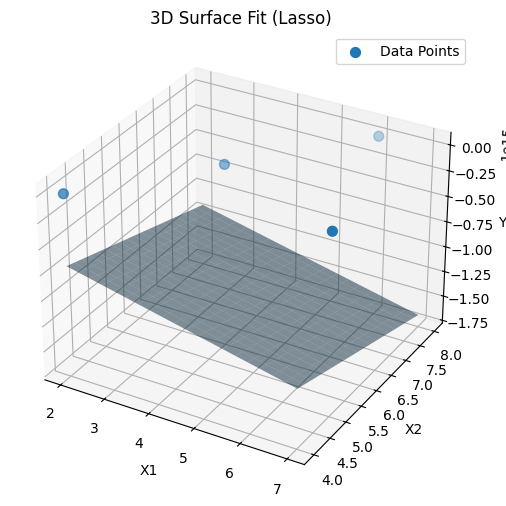

In [18]:
import numpy as np
import matplotlib.pyplot as plt


def lasso_regression_gd(x1, x2, y, learning_rate, n_iterations, lambda_param):

    n = len(y)

    w1 = 0.0
    w2 = 0.033
    b = 0.0

    cost_history = []

    for i in range(n_iterations):

        y_predicted = w1 * x1 + w2 * x2 + b

        error = y_predicted - y

        dw1 = (1 / n) * np.sum(error * x1) + lambda_param * np.sign(w1)

        dw2 = (1 / n) * np.sum(error * x2) + lambda_param * np.sign(w2)

        db = (1 / n) * np.sum(error)

        w1 = w1 - learning_rate * dw1

        w2 = w2 - learning_rate * dw2

        b = b - learning_rate * db

        cost = (
            (1 / (2 * n)) * np.sum(error ** 2)
            + lambda_param * (abs(w1) + abs(w2))
        )

        cost_history.append(cost)

    return w1, w2, b, cost_history


x1_input = input("Enter x1 values: ")
x2_input = input("Enter x2 values: ")
y_input = input("Enter target y values: ")

x1 = np.array([
    float(value.strip())
    for value in x1_input.split(",")
])

x2 = np.array([
    float(value.strip())
    for value in x2_input.split(",")
])

y = np.array([
    float(value.strip())
    for value in y_input.split(",")
])


if len(x1) != len(x2) or len(x1) != len(y):

    print("Error: x1, x2 and y must have the same number of values.")

else:

    learning_rate = float(input("Enter learning rate: "))
    n_iterations = int(input("Enter number of iterations: "))
    lambda_param = float(input("Enter lambda: "))

    w1, w2, b, cost_history = lasso_regression_gd(
        x1,
        x2,
        y,
        learning_rate,
        n_iterations,
        lambda_param
    )

    print("\nFinal Parameters:")
    print("w1 =", round(w1, 4))
    print("w2 =", round(w2, 4))
    print("b =", round(b, 4))


    plt.figure()

    plt.plot(
        range(1, n_iterations + 1),
        cost_history
    )

    plt.xlabel("Iteration")
    plt.ylabel("Cost J(w1,w2,b)")
    plt.title("Lasso Regression Cost History")
    plt.grid(True)

    plt.show()


    fig = plt.figure(figsize=(8, 6))

    ax = fig.add_subplot(
        111,
        projection="3d"
    )


    ax.scatter(
        x1,
        x2,
        y,
        s=50,
        label="Data Points"
    )


    x1_grid = np.linspace(
        min(x1),
        max(x1),
        20
    )

    x2_grid = np.linspace(
        min(x2),
        max(x2),
        20
    )


    x1_grid, x2_grid = np.meshgrid(
        x1_grid,
        x2_grid
    )


    y_grid = (
        w1 * x1_grid
        + w2 * x2_grid
        + b
    )


    ax.plot_surface(
        x1_grid,
        x2_grid,
        y_grid,
        alpha=0.5
    )


    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("Y")

    ax.set_title("3D Surface Fit (Lasso)")

    ax.legend()
    plt.show()